# Insurance Charges Prediction - Fixed

Complete, error-free notebook for insurance.csv dataset.

In [47]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings('ignore')

In [48]:
df = pd.read_csv('insurance.csv')
print(df.shape)
print(df.columns)
df.head()

(1338, 7)
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [49]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## EDA

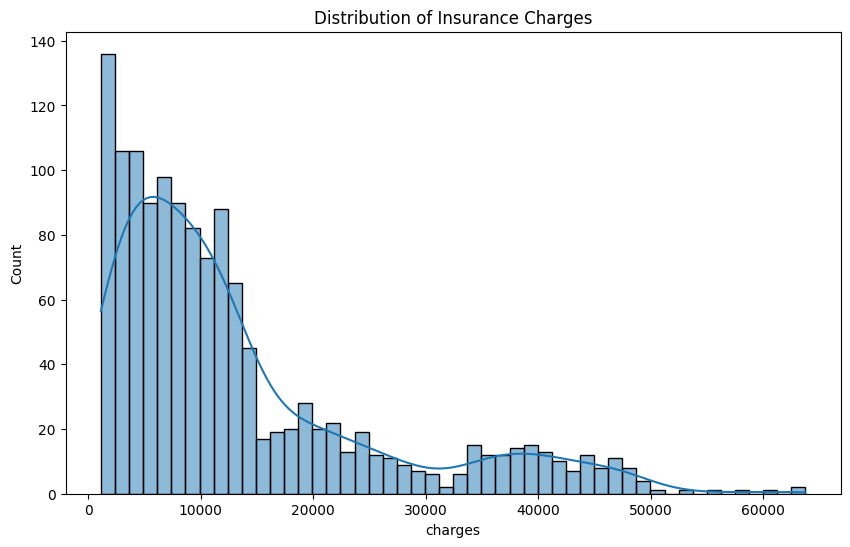

In [50]:
plt.figure(figsize=(10,6))
sns.histplot(df['charges'], bins=50, kde=True)
plt.title('Distribution of Insurance Charges')
plt.show()

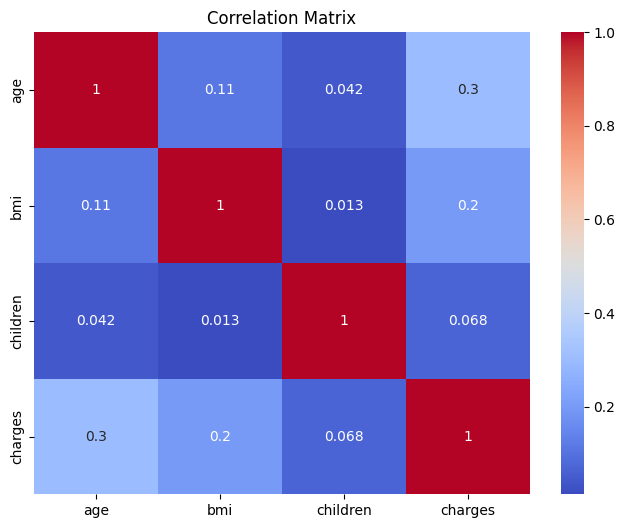

In [51]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

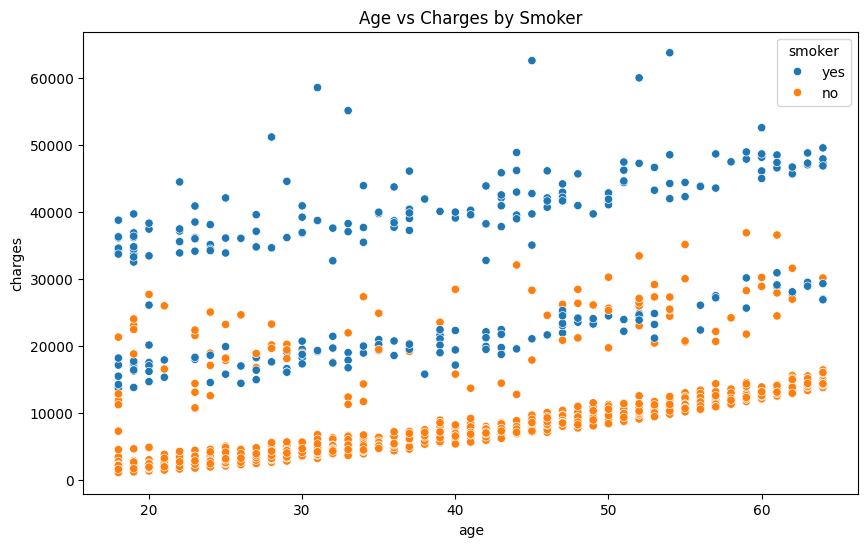

In [52]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker')
plt.title('Age vs Charges by Smoker')
plt.show()

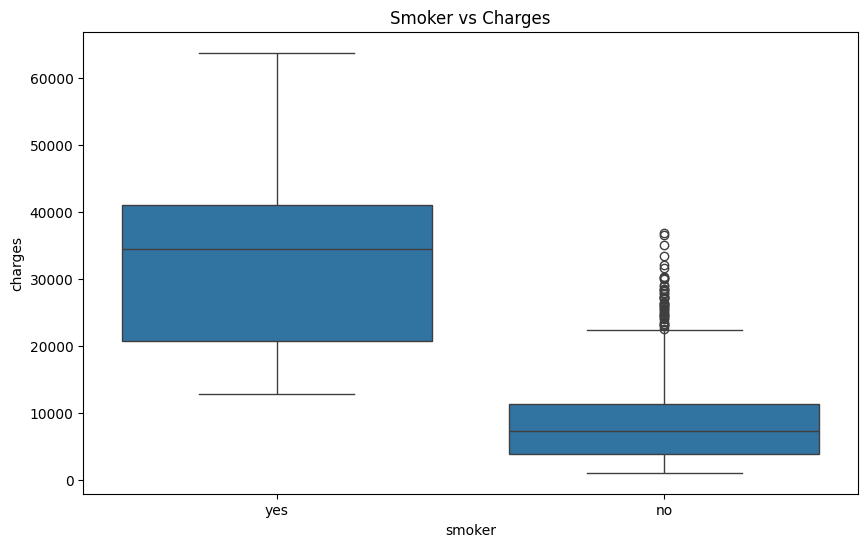

In [53]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='smoker', y='charges')
plt.title('Smoker vs Charges')
plt.show()

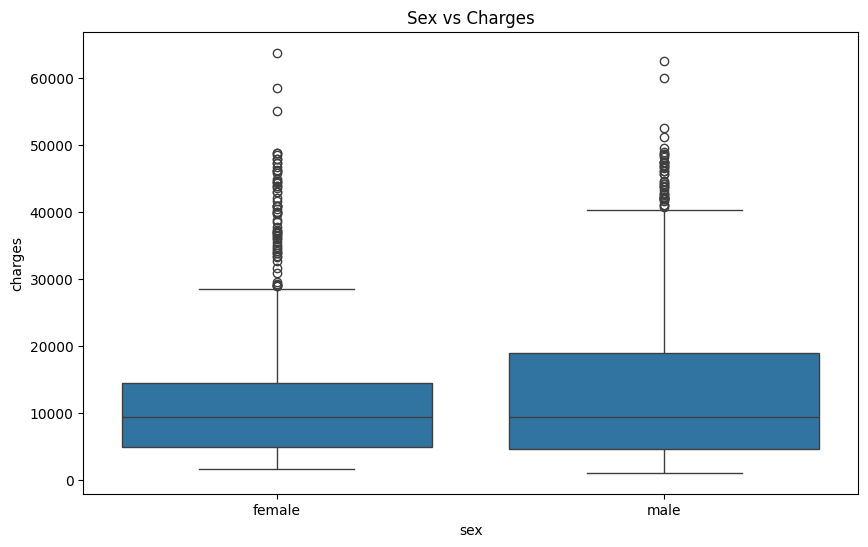

In [54]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='sex', y='charges')
plt.title('Sex vs Charges')
plt.show()

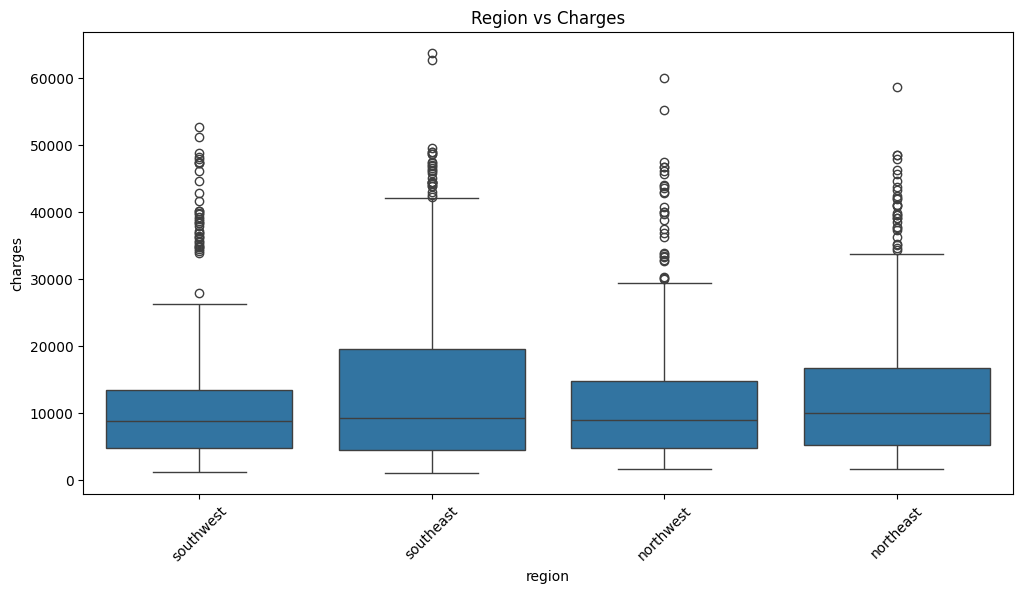

In [55]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='region', y='charges')
plt.title('Region vs Charges')
plt.xticks(rotation=45)
plt.show()

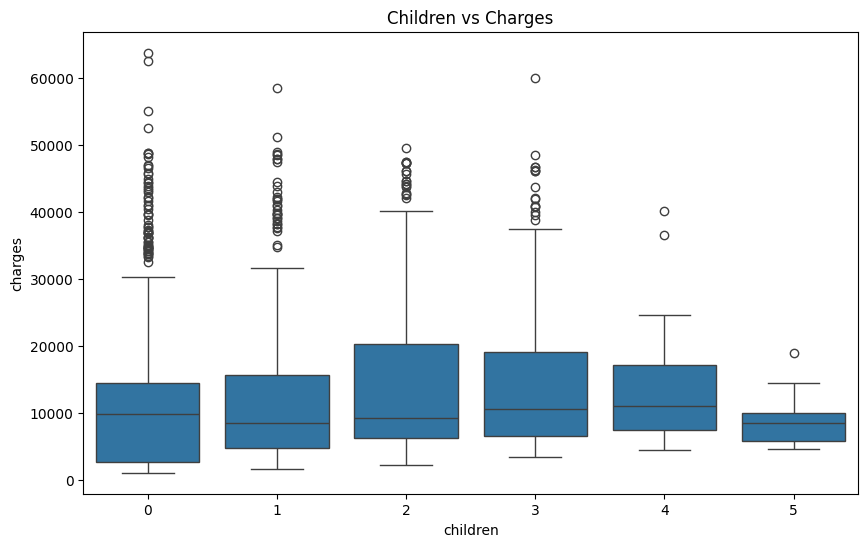

In [56]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='children', y='charges')
plt.title('Children vs Charges')
plt.show()

## Preprocessing

In [57]:
X = df.drop('charges', axis=1)
y = df['charges']
print(X.shape, y.shape)

(1338, 6) (1338,)


In [58]:
X_encoded = pd.get_dummies(X, columns=['sex', 'smoker', 'region'], drop_first=True)
print(X_encoded.head())

   age     bmi  children  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0     False        True             False   
1   18  33.770         1      True       False             False   
2   28  33.000         3      True       False             False   
3   33  22.705         0      True       False              True   
4   32  28.880         0      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['age', 'bmi', 'children']
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])
X_encoded.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-1.438764,-0.453320,-0.908614,False,True,False,False,True
1,-1.509965,0.509621,-0.078767,True,False,False,True,False
2,-0.797954,0.383307,1.580926,True,False,False,True,False
3,-0.441948,-1.305531,-0.908614,True,False,True,False,False
4,-0.513149,-0.292556,-0.908614,True,False,True,False,False


## Linear Regression Model

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.33, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f'R² Score: {r2:.4f}')

n = len(y_test)
p = X_test.shape[1]
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
print(f'Adjusted R²: {adj_r2:.4f}')

R² Score: 0.7605
Adjusted R²: 0.7561


NameError: name 'final_df' is not defined